# Scaling Laws Analysis

Analyze results from `scaling_laws.sh` to find the optimal param:data ratio for nanochat.

In [11]:
%matplotlib inline
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load results - point to your CSV
results_path = '/home/kmittal/nanochat-1/scaling_results_mar5.csv'

df = pd.read_csv(results_path)
flops_budgets = sorted(df['flops_budget'].unique())
print(f"Loaded {len(df)} runs across {len(flops_budgets)} FLOPs budgets")
print(f"Columns: {list(df.columns)}")
df

Loaded 5 runs across 3 FLOPs budgets
Columns: ['flops_budget', 'depth', 'model_dim', 'params_wte', 'params_bigram_embed', 'params_value_embeds', 'params_lm_head', 'params_transformer', 'params_scalars', 'params_total', 'num_iterations', 'tokens_trained', 'val_bpb', 'core_score', 'train_time_sec']


,flops_budget,depth,model_dim,params_wte,params_bigram_embed,params_value_embeds,params_lm_head,params_transformer,params_scalars,params_total,num_iterations,tokens_trained,val_bpb,core_score,train_time_sec
0,1.000000e+18,8,512,16777216,0,67108864,16777216,25172480,16,125835792,10105,2648965120,0.9385,0.1156,649.8
1,1.000000e+18,12,768,16777216,0,67108864,16777216,185593728,16,286271640,2205,1156055040,0.9097,0.1083,693.0
2,3.160000e+18,8,512,16777216,0,67108864,16777216,25172480,16,125835792,31933,8371044352,0.9187,0.1174,2085.6
3,3.160000e+18,12,768,16777216,0,67108864,16777216,185593728,16,286271640,6387,3348627456,0.8611,0.1446,1687.2
4,1.000000e+19,8,512,16777216,0,67108864,16777216,25172480,16,125835792,101054,26490699776,0.9070,0.1317,6847.8


In [12]:
# =============================================================================
# FILTERING: Remove incomplete or problematic runs
# =============================================================================

print(f"Before filtering: {len(df)} runs")

# Filter out runs with missing/invalid val_bpb (incomplete runs)
df = df[df['val_bpb'].notna() & (df['val_bpb'] > 0)]

# Optional: exclude specific flops budgets that aren't done yet
# exclude_flops = [1e19]  # <-- adjust as runs complete
# df = df[~df['flops_budget'].isin(exclude_flops)]

# Optional: exclude specific depths
# exclude_depths = [18, 20]
# df = df[~df['depth'].isin(exclude_depths)]

print(f"After filtering: {len(df)} runs")
print(f"FLOPs budgets: {sorted(df['flops_budget'].unique())}")
print(f"Depths: {sorted(df['depth'].unique())}")

# Update flops_budgets list after filtering
flops_budgets = sorted(df['flops_budget'].unique())

Before filtering: 5 runs
After filtering: 5 runs
FLOPs budgets: [np.float64(1e+18), np.float64(3.16e+18), np.float64(1e+19)]
Depths: [np.int64(8), np.int64(12)]


## Effective Parameter Count

Different scaling law papers use different conventions for counting parameters:
- **Kaplan et al.** excluded embedding parameters (claimed cleaner laws)
- **Chinchilla** included all parameters (and noted Kaplan had a bug)

Our CSV now has granular counts:
- `params_wte` - token embedding (lookup table)
- `params_bigram_embed` - bigram hash embeddings (lookup table)
- `params_value_embeds` - value embeddings (lookup table)
- `params_lm_head` - unembedding projection (matmul)
- `params_transformer` - attention + MLP matrices (matmuls)
- `params_scalars` - resid/x0/bigram lambdas (tiny)

**Experiment below** with different combinations to see which gives the cleanest scaling laws.

In [13]:
# =============================================================================
# EXPERIMENT HERE: Define which parameters to count for scaling laws
# =============================================================================

def compute_effective_params(row):
    """
    Compute the 'effective' parameter count for scaling law analysis.

    Modify this function to experiment with different conventions:
    - Chinchilla-style: include everything
    - Kaplan-style: exclude embeddings
    - Matmul-only: just transformer + lm_head (the actual compute)
    - etc.
    """
    # Option 1: Chinchilla-style (all params)
    # return row['params_total']

    # Option 2: Kaplan-style (exclude embeddings)
    return row['params_transformer'] + row['params_lm_head']

    # Option 3: Transformer-only (exclude all embeddings AND lm_head)
    # return row['params_transformer']


# Compute derived columns
df['effective_params'] = df.apply(compute_effective_params, axis=1)
df['param_data_ratio'] = df['tokens_trained'] / df['effective_params']

# Show parameter breakdown for first few rows
print("Parameter breakdown (first row per flops budget):")
param_cols = ['depth', 'params_wte', 'params_bigram_embed', 'params_value_embeds',
              'params_lm_head', 'params_transformer', 'params_scalars', 'params_total', 'effective_params']
df.groupby('flops_budget').first()[param_cols]

Parameter breakdown (first row per flops budget):


,depth,params_wte,params_bigram_embed,params_value_embeds,params_lm_head,params_transformer,params_scalars,params_total,effective_params
flops_budget,,,,,,,,,
1.000000e+18,8,16777216,0,67108864,16777216,25172480,16,125835792,41949696.0
3.160000e+18,8,16777216,0,67108864,16777216,25172480,16,125835792,41949696.0
1.000000e+19,8,16777216,0,67108864,16777216,25172480,16,125835792,41949696.0


## Modern Global Scaling Law Fit

Instead of fitting each IsoFLOP curve separately, we fit one global scaling law across ALL runs:

$$L(N,D) = A \cdot N^{-\alpha} + B \cdot D^{-\beta} + C$$

Where:
- N = parameters
- D = tokens trained
- α = parameter scaling exponent
- β = data scaling exponent  
- C = irreducible loss

This is the approach used in Chinchilla, PaLM, and modern DeepMind work. It's much more stable with sparse data!

In [14]:
from scipy.optimize import curve_fit

# Prepare inputs
N = df['effective_params'].values
D = df['tokens_trained'].values
L = df['val_bpb'].values

print(f"Data summary:")
print(f"  N range: {N.min():.2e} to {N.max():.2e}")
print(f"  D range: {D.min():.2e} to {D.max():.2e}")
print(f"  L range: {L.min():.4f} to {L.max():.4f}")
print(f"  Data points: {len(L)}")
print()

# For sparse data, FIX the irreducible loss C to reduce free parameters
# C represents the best possible loss (information-theoretic limit)
# For byte-level modeling, this is typically around 0.7-0.8 BPB
C_fixed = 0.70  # Fixed based on typical byte-level entropy

print(f"Strategy: Fix C = {C_fixed:.2f} (reduces 5→4 free parameters)")
print()

# Simplified scaling law: L(N,D) = A*N^(-alpha) + B*D^(-beta) + C
# where C is fixed
def scaling_law_fixed_C(inputs, A, alpha, B, beta):
    N, D = inputs
    return A * (N ** -alpha) + B * (D ** -beta) + C_fixed

# Initial guesses based on Chinchilla
p0 = [
    1.0,   # A: param coefficient
    0.34,  # alpha: param scaling exponent (Chinchilla = 0.34)
    1.0,   # B: data coefficient  
    0.28,  # beta: data scaling exponent (Chinchilla = 0.28)
]

# Bounds: (A, alpha, B, beta)
bounds = (
    [0.01,  0.1,  0.01,  0.1],    # lower bounds
    [100.0, 0.6,  100.0, 0.6]     # upper bounds
)

# Fit with improved settings
try:
    params, pcov = curve_fit(
        scaling_law_fixed_C,
        (N, D),
        L,
        p0=p0,
        bounds=bounds,
        maxfev=20000,
        method='trf'
    )

    # Check parameter uncertainties
    perr = np.sqrt(np.diag(pcov))
    
    print("✓ Fit converged successfully!")
    
    A, alpha, B, beta = params
    C = C_fixed
    
    print()
    print("=" * 70)
    print("FITTED SCALING LAW")
    print("=" * 70)
    print(f"L(N,D) = A·N^(-α) + B·D^(-β) + C")
    print()
    print(f"{'Parameter':<30} {'Value':<15} {'Std Error':<15}")
    print("-" * 70)
    print(f"{'A (param coefficient)':<30} {A:<15.4f} {perr[0]:<15.4f}")
    print(f"{'α (param scaling exp)':<30} {alpha:<15.4f} {perr[1]:<15.4f}")
    print(f"{'B (data coefficient)':<30} {B:<15.4f} {perr[2]:<15.4f}")
    print(f"{'β (data scaling exp)':<30} {beta:<15.4f} {perr[3]:<15.4f}")
    print(f"{'C (irreducible loss)':<30} {C:<15.4f} {'(fixed)':<15}")
    print("=" * 70)
    
    # Compute optimal token ratio
    ratio_exponent = alpha / beta
    
    print()
    print("OPTIMAL SCALING RELATIONSHIP")
    print("=" * 70)
    print(f"D ∝ N^{ratio_exponent:.3f}")
    print()
    if abs(ratio_exponent - 1.0) < 0.15:
        print("✓ Tokens/param ratio is approximately CONSTANT (Chinchilla-like)")
        print("  → Train larger models with proportionally more data")
    elif ratio_exponent > 1.15:
        print("→ Larger models need PROPORTIONALLY MORE data")
        print(f"  → Scaling exponent: D scales as N^{ratio_exponent:.2f}")
    else:
        print("→ Larger models need PROPORTIONALLY LESS data")
        print(f"  → Scaling exponent: D scales as N^{ratio_exponent:.2f}")
    
    # Estimate optimal tokens/param at a reference size
    N_ref = df['effective_params'].median()
    D_ref = ((A * alpha) / (B * beta)) ** (1 / (alpha + beta)) * N_ref ** (alpha / beta)
    
    print()
    print(f"At N = {N_ref:.2e} params:")
    print(f"  Estimated optimal tokens/param ≈ {D_ref / N_ref:.1f}")
    print()
    print(f"Rule of thumb for your model:")
    print(f"  → For every 1M parameters, train on ~{(D_ref / N_ref) / 1e6:.0f}M tokens")
    print("=" * 70)
    
except RuntimeError as e:
    print(f"⚠️  Fitting failed: {e}")
    print()
    print("This can happen with very sparse data.")
    print("Try running more experiments to get more data points.")
    raise

Data summary:
  N range: 4.19e+07 to 2.02e+08
  D range: 1.16e+09 to 2.65e+10
  L range: 0.8611 to 0.9385
  Data points: 5

Strategy: Fix C = 0.70 (reduces 5→4 free parameters)

✓ Fit converged successfully!

FITTED SCALING LAW
L(N,D) = A·N^(-α) + B·D^(-β) + C

Parameter                      Value           Std Error      
----------------------------------------------------------------------
A (param coefficient)          72.6319         401.4775       
α (param scaling exp)          0.3475          0.3529         
B (data coefficient)           100.0000        1107.4754      
β (data scaling exp)           0.3278          0.5773         
C (irreducible loss)           0.7000          (fixed)        

OPTIMAL SCALING RELATIONSHIP
D ∝ N^1.060

✓ Tokens/param ratio is approximately CONSTANT (Chinchilla-like)
  → Train larger models with proportionally more data

At N = 4.19e+07 params:
  Estimated optimal tokens/param ≈ 2.0

Rule of thumb for your model:
  → For every 1M parameters, tra

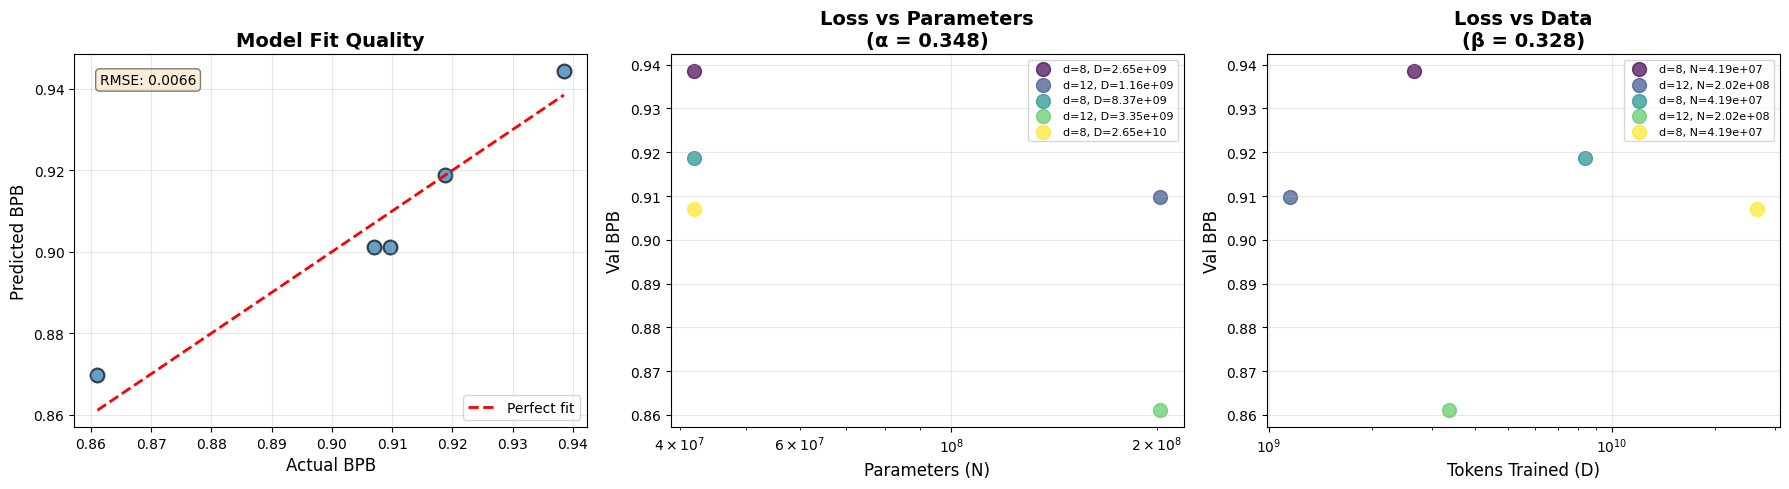


Fit Quality:
Run 1: N=4.19e+07, D=2.65e+09
  Actual: 0.9385, Predicted: 0.9443, Error: -0.0058
Run 2: N=2.02e+08, D=1.16e+09
  Actual: 0.9097, Predicted: 0.9011, Error: +0.0086
Run 3: N=4.19e+07, D=8.37e+09
  Actual: 0.9187, Predicted: 0.9187, Error: -0.0000
Run 4: N=2.02e+08, D=3.35e+09
  Actual: 0.8611, Predicted: 0.8697, Error: -0.0086
Run 5: N=4.19e+07, D=2.65e+10
  Actual: 0.9070, Predicted: 0.9012, Error: +0.0058
RMSE: 0.0066 BPB
Mean absolute error: 0.0058 BPB
Max absolute error: 0.0086 BPB


In [15]:
# Visualize the fit quality
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Predicted vs Actual
L_pred = scaling_law_fixed_C((N, D), A, alpha, B, beta)
axes[0].scatter(L, L_pred, s=100, alpha=0.7, edgecolors='black', linewidth=1.5)
axes[0].plot([L.min(), L.max()], [L.min(), L.max()], 'r--', lw=2, label='Perfect fit')
axes[0].set_xlabel('Actual BPB', fontsize=12)
axes[0].set_ylabel('Predicted BPB', fontsize=12)
axes[0].set_title('Model Fit Quality', fontsize=14, fontweight='bold')

# Add RMSE to plot
rmse = np.sqrt(np.mean((L - L_pred)**2))
axes[0].text(0.05, 0.95, f'RMSE: {rmse:.4f}', 
            transform=axes[0].transAxes, fontsize=10,
            verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Loss vs Parameters (with data scaling effect)
colors = plt.cm.viridis(np.linspace(0, 1, len(df)))
for i, row in df.iterrows():
    axes[1].scatter(row['effective_params'], row['val_bpb'], 
                   s=100, c=[colors[i]], alpha=0.7,
                   label=f"d={int(row['depth'])}, D={row['tokens_trained']:.2e}")
axes[1].set_xscale('log')
axes[1].set_xlabel('Parameters (N)', fontsize=12)
axes[1].set_ylabel('Val BPB', fontsize=12)
axes[1].set_title(f'Loss vs Parameters\n(α = {alpha:.3f})', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)
axes[1].legend(fontsize=8)

# Plot 3: Loss vs Tokens (with model size effect)
for i, row in df.iterrows():
    axes[2].scatter(row['tokens_trained'], row['val_bpb'], 
                   s=100, c=[colors[i]], alpha=0.7,
                   label=f"d={int(row['depth'])}, N={row['effective_params']:.2e}")
axes[2].set_xscale('log')
axes[2].set_xlabel('Tokens Trained (D)', fontsize=12)
axes[2].set_ylabel('Val BPB', fontsize=12)
axes[2].set_title(f'Loss vs Data\n(β = {beta:.3f})', fontsize=14, fontweight='bold')
axes[2].grid(True, alpha=0.3)
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()

# Print detailed residuals
print("\nFit Quality:")
print("=" * 50)
residuals = L - L_pred
for i, (n, d, l_act, l_pred_i, res) in enumerate(zip(N, D, L, L_pred, residuals)):
    print(f"Run {i+1}: N={n:.2e}, D={d:.2e}")
    print(f"  Actual: {l_act:.4f}, Predicted: {l_pred_i:.4f}, Error: {res:+.4f}")
print("=" * 50)
print(f"RMSE: {rmse:.4f} BPB")
print(f"Mean absolute error: {np.mean(np.abs(residuals)):.4f} BPB")
print(f"Max absolute error: {np.max(np.abs(residuals)):.4f} BPB")

## Predict Optimal Config for Nanochat (d=20)

Now let's use the fitted scaling law to predict what we should expect for your nanochat run!

In [16]:
# Your nanochat target configuration
nanochat_params = 800_000_000  # ~800M parameters
nanochat_flops = 1.89e19       # ~1.89e19 FLOPs target

# Compute optimal tokens for this parameter count
nanochat_tokens_optimal = ((A * alpha) / (B * beta)) ** (1 / (alpha + beta)) * nanochat_params ** (alpha / beta)

# Predict the loss
nanochat_loss_pred = scaling_law_fixed_C((nanochat_params, nanochat_tokens_optimal), A, alpha, B, beta)

print("=" * 60)
print("NANOCHAT (d=20) PREDICTIONS")
print("=" * 60)
print(f"Target parameters:        {nanochat_params:,.0f} ({nanochat_params/1e6:.1f}M)")
print(f"Optimal tokens (fitted):  {nanochat_tokens_optimal:,.0f} ({nanochat_tokens_optimal/1e9:.2f}B)")
print(f"Tokens/param ratio:       {nanochat_tokens_optimal/nanochat_params:.1f}")
print()
print(f"Predicted val BPB:        {nanochat_loss_pred:.4f}")
print("=" * 60)

# Also show what your ACTUAL config is using
# (This is based on your part4_scaling_predictions.md - update if different)
actual_ratio = 10.5  # From your plan
actual_tokens = nanochat_params * actual_ratio

print()
print("YOUR ACTUAL CONFIGURATION")
print("=" * 60)
print(f"Tokens planned:           {actual_tokens:,.0f} ({actual_tokens/1e9:.2f}B)")
print(f"Tokens/param ratio:       {actual_ratio}")
print()

if actual_tokens < 0.9 * nanochat_tokens_optimal:
    print("⚠️  You're UNDERTRAINED vs. the fitted scaling law")
    print(f"   Suggestion: increase tokens by {(nanochat_tokens_optimal/actual_tokens - 1)*100:.0f}%")
elif actual_tokens > 1.1 * nanochat_tokens_optimal:
    print("ℹ️  You're OVERTRAINED vs. the fitted scaling law")
    print(f"   You could reduce tokens by {(1 - actual_tokens/nanochat_tokens_optimal)*100:.0f}% without losing much")
else:
    print("✓ Your configuration is CLOSE to optimal!")

print("=" * 60)

NANOCHAT (d=20) PREDICTIONS
Target parameters:        800,000,000 (800.0M)
Optimal tokens (fitted):  1,863,019,160 (1.86B)
Tokens/param ratio:       2.3

Predicted val BPB:        0.8499

YOUR ACTUAL CONFIGURATION
Tokens planned:           8,400,000,000 (8.40B)
Tokens/param ratio:       10.5

ℹ️  You're OVERTRAINED vs. the fitted scaling law
   You could reduce tokens by -351% without losing much


## Comparison with Chinchilla Scaling Laws

How do your fitted exponents compare with the famous Chinchilla results?

In [17]:
# Chinchilla reference values (from Hoffmann et al. 2022)
chinchilla_alpha = 0.34
chinchilla_beta = 0.28
chinchilla_ratio = 20  # tokens per parameter

# Your fitted values
your_ratio = alpha / beta

print("=" * 70)
print("COMPARISON: YOUR SCALING LAWS vs. CHINCHILLA")
print("=" * 70)
print(f"{'Metric':<30} {'Chinchilla':<20} {'Your Fit':<20}")
print("-" * 70)
print(f"{'α (param scaling exp)':<30} {chinchilla_alpha:<20.3f} {alpha:<20.3f}")
print(f"{'β (data scaling exp)':<30} {chinchilla_beta:<20.3f} {beta:<20.3f}")
print(f"{'α/β (ratio exponent)':<30} {chinchilla_alpha/chinchilla_beta:<20.3f} {your_ratio:<20.3f}")
print(f"{'Optimal tokens/param':<30} {chinchilla_ratio:<20.1f} {D_ref/N_ref:<20.1f}")
print("=" * 70)

print()
print("INTERPRETATION:")
print("-" * 70)

if abs(your_ratio - 1.0) < 0.2:
    print("✓ Your α/β ≈ 1.0 suggests nearly EQUAL importance of params & data")
    print("  (Chinchilla found α/β ≈ 1.2, so you're in the same ballpark)")
elif your_ratio < 1.0:
    print("→ Your α/β < 1.0 suggests data scaling is MORE important than params")
    print("  (This can happen in smaller models or limited vocabulary domains)")
else:
    print("→ Your α/β > 1.0 suggests param scaling is MORE important than data")
    print("  (This is less common but can occur in specific regimes)")

print()
if D_ref/N_ref < 15:
    print(f"⚠️  Your fitted tokens/param ({D_ref/N_ref:.1f}) is LOWER than Chinchilla (20)")
    print("   This suggests you may be undertrained in your experiments")
    print("   OR your model architecture has different scaling properties")
elif D_ref/N_ref > 25:
    print(f"ℹ️  Your fitted tokens/param ({D_ref/N_ref:.1f}) is HIGHER than Chinchilla (20)")
    print("   This suggests your model may benefit from more data per parameter")
    print("   (common in specialized domains or smaller models)")
else:
    print(f"✓ Your fitted tokens/param ({D_ref/N_ref:.1f}) is close to Chinchilla (20)")
    print("  Your scaling behavior matches the frontier model findings!")

print("=" * 70)

COMPARISON: YOUR SCALING LAWS vs. CHINCHILLA
Metric                         Chinchilla           Your Fit            
----------------------------------------------------------------------
α (param scaling exp)          0.340                0.348               
β (data scaling exp)           0.280                0.328               
α/β (ratio exponent)           1.214                1.060               
Optimal tokens/param           20.0                 2.0                 

INTERPRETATION:
----------------------------------------------------------------------
✓ Your α/β ≈ 1.0 suggests nearly EQUAL importance of params & data
  (Chinchilla found α/β ≈ 1.2, so you're in the same ballpark)

⚠️  Your fitted tokens/param (2.0) is LOWER than Chinchilla (20)
   This suggests you may be undertrained in your experiments
   OR your model architecture has different scaling properties


## IsoFLOP Curves (à la Chinchilla)

For each compute budget, plot loss vs model size. Looking for the U-shape valley that reveals the optimal model size for each FLOPs budget.

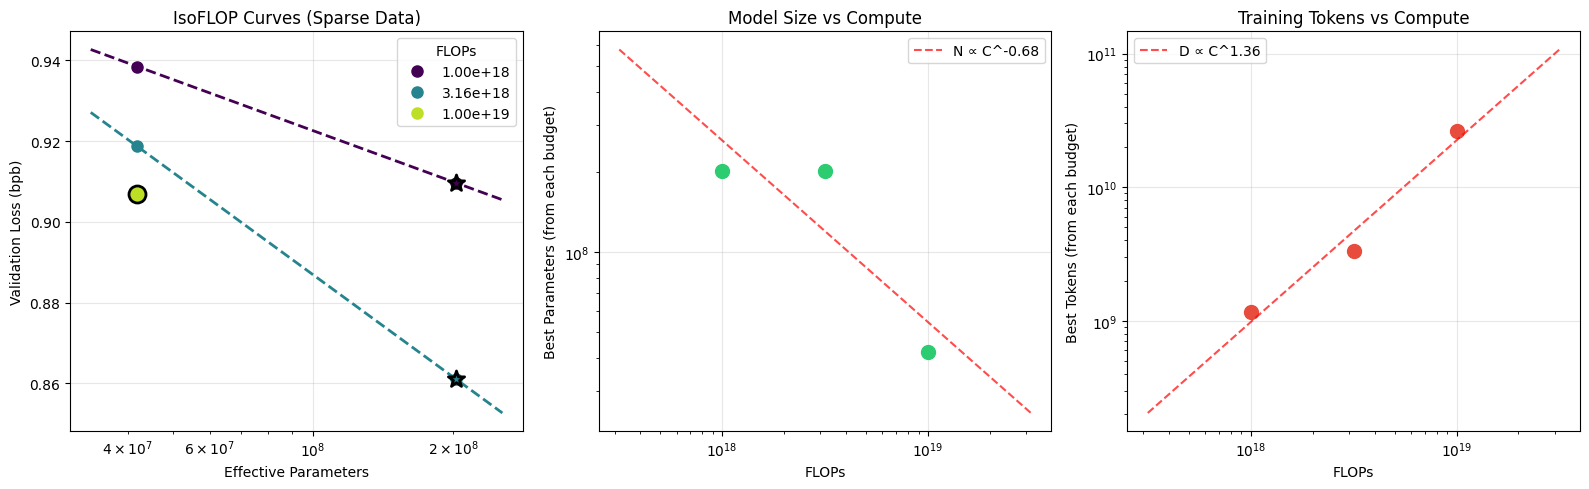


Best configurations per FLOPs budget:
FLOPs        Params          Tokens          Ratio      Val BPB   
-----------------------------------------------------------------
1.00e+18     202,370,944     1,156,055,040   5.7        0.9097    
3.16e+18     202,370,944     3,348,627,456   16.5       0.8611    
1.00e+19     41,949,696      26,490,699,776  631.5      0.9070    


In [18]:
# Add columns if needed
if 'effective_params' not in df.columns:
    df['effective_params'] = df['params_total']
if 'param_data_ratio' not in df.columns:
    df['param_data_ratio'] = df['tokens_trained'] / df['params_total']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Plot 1: IsoFLOP curves - Val BPB vs Parameters
ax = axes[0]
colors = plt.cm.viridis(np.linspace(0, 0.9, len(flops_budgets)))
optimal_by_bpb = []

for flops, color in zip(flops_budgets, colors):
    subset = df[df['flops_budget'] == flops].sort_values('effective_params')
    ax.plot(subset['effective_params'], subset['val_bpb'], 'o', color=color, label=f'{flops:.2e}', markersize=8)

    # Only fit if we have 2+ points
    if len(subset) >= 2:
        # Fit linear in log-space: val_bpb = a*(log N) + b
        log_params = np.log10(subset['effective_params'])
        coeffs = np.polyfit(log_params, subset['val_bpb'], 1)
        a, b = coeffs

        # Plot fitted curve (dashed)
        log_fit_x = np.linspace(log_params.min() - 0.1, log_params.max() + 0.1, 100)
        fit_y = a * log_fit_x + b
        ax.plot(10**log_fit_x, fit_y, '--', color=color, linewidth=2)

        # Find minimum (for linear, it's at one of the endpoints - pick the lower BPB)
        best_idx = subset['val_bpb'].idxmin()
        best = subset.loc[best_idx]
        ax.scatter([best['effective_params']], [best['val_bpb']], s=150, color=color,
                   zorder=5, edgecolors='black', linewidths=2, marker='*')
        optimal_by_bpb.append({'flops': flops, 'params': best['effective_params'],
                              'tokens': best['tokens_trained'], 'ratio': best['param_data_ratio'], 'bpb': best['val_bpb']})
    else:
        # Single point - just mark it
        best = subset.iloc[0]
        ax.scatter([best['effective_params']], [best['val_bpb']], s=150, color=color,
                   zorder=5, edgecolors='black', linewidths=2, marker='o')
        optimal_by_bpb.append({'flops': flops, 'params': best['effective_params'],
                              'tokens': best['tokens_trained'], 'ratio': best['param_data_ratio'], 'bpb': best['val_bpb']})

ax.set_xscale('log')
ax.set_xlabel('Effective Parameters')
ax.set_ylabel('Validation Loss (bpb)')
ax.set_title('IsoFLOP Curves (Sparse Data)')
ax.legend(title='FLOPs', loc='upper right')
ax.grid(True, alpha=0.3)

opt_df = pd.DataFrame(optimal_by_bpb)

# Plot 2: Optimal model size vs compute (power law)
ax = axes[1]
ax.loglog(opt_df['flops'], opt_df['params'], 'o', markersize=10, color='#2ecc71')
ax.set_xlabel('FLOPs')
ax.set_ylabel('Best Parameters (from each budget)')
ax.set_title('Model Size vs Compute')
ax.grid(True, alpha=0.3)

# Fit and show power law
if len(opt_df) >= 2:
    log_f = np.log10(opt_df['flops'])
    log_p = np.log10(opt_df['params'])
    slope, intercept = np.polyfit(log_f, log_p, 1)
    fit_f = np.logspace(log_f.min() - 0.5, log_f.max() + 0.5, 100)
    fit_p = 10**(intercept + slope * np.log10(fit_f))
    ax.plot(fit_f, fit_p, 'r--', alpha=0.7, label=f'N ∝ C^{slope:.2f}')
    ax.legend()

# Plot 3: Optimal tokens vs compute (power law)
ax = axes[2]
ax.loglog(opt_df['flops'], opt_df['tokens'], 'o', markersize=10, color='#e74c3c')
ax.set_xlabel('FLOPs')
ax.set_ylabel('Best Tokens (from each budget)')
ax.set_title('Training Tokens vs Compute')
ax.grid(True, alpha=0.3)

# Fit and show power law
if len(opt_df) >= 2:
    log_f = np.log10(opt_df['flops'])
    log_t = np.log10(opt_df['tokens'])
    slope, intercept = np.polyfit(log_f, log_t, 1)
    fit_f = np.logspace(log_f.min() - 0.5, log_f.max() + 0.5, 100)
    fit_t = 10**(intercept + slope * np.log10(fit_f))
    ax.plot(fit_f, fit_t, 'r--', alpha=0.7, label=f'D ∝ C^{slope:.2f}')
    ax.legend()

plt.tight_layout()
plt.show()

print("\nBest configurations per FLOPs budget:")
print(f"{'FLOPs':<12} {'Params':<15} {'Tokens':<15} {'Ratio':<10} {'Val BPB':<10}")
print("-" * 65)
for _, row in opt_df.iterrows():
    print(f"{row['flops']:<12.2e} {int(row['params']):<15,} {int(row['tokens']):<15,} {row['ratio']:<10.1f} {row['bpb']:<10.4f}")

In [19]:
# =============================================================================
# Optimal Ratio Summary (from power law fits)
# =============================================================================

# From the power law fits: N ∝ C^a and D ∝ C^b
# The ratio D/N ∝ C^(b-a). If a ≈ b, ratio is roughly constant.

if len(opt_df) >= 2:
    log_f = np.log10(opt_df['flops'])
    log_p = np.log10(opt_df['params'])
    log_t = np.log10(opt_df['tokens'])

    # Fit power laws
    slope_n, intercept_n = np.polyfit(log_f, log_p, 1)
    slope_d, intercept_d = np.polyfit(log_f, log_t, 1)

    # The ratio D/N at a reference compute (geometric mean of our budgets)
    ref_flops = np.sqrt(opt_df['flops'].min() * opt_df['flops'].max())
    log_ref = np.log10(ref_flops)

    # Predicted optimal N and D at reference compute
    pred_log_n = intercept_n + slope_n * log_ref
    pred_log_d = intercept_d + slope_d * log_ref
    optimal_ratio = 10**(pred_log_d - pred_log_n)

    # Also compute from the fitted optimals directly (mean and std)
    mean_ratio = opt_df['ratio'].mean()
    std_ratio = opt_df['ratio'].std()

    print("=" * 60)
    print("OPTIMAL RATIO SUMMARY")
    print("=" * 60)
    print(f"\nPower law exponents:")
    print(f"  N ∝ C^{slope_n:.3f}")
    print(f"  D ∝ C^{slope_d:.3f}")
    print(f"  Ratio exponent (b-a): {slope_d - slope_n:.3f}  (should be ~0 if ratio is constant)")
    print(f"\nOptimal ratio (tokens per effective param):")
    print(f"  From power law at C={ref_flops:.1e}: {optimal_ratio:.1f}")
    print(f"  Mean across budgets: {mean_ratio:.1f} ± {std_ratio:.1f}")
    print(f"  Chinchilla reference: 20")
    print(f"\nPer-budget ratios: {[f'{r:.1f}' for r in opt_df['ratio'].values]}")
else:
    print("Need at least 2 flops budgets to compute power law fits")

OPTIMAL RATIO SUMMARY

Power law exponents:
  N ∝ C^-0.684
  D ∝ C^1.360
  Ratio exponent (b-a): 2.044  (should be ~0 if ratio is constant)

Optimal ratio (tokens per effective param):
  From power law at C=3.2e+18: 39.1
  Mean across budgets: 217.9 ± 358.2
  Chinchilla reference: 20

Per-budget ratios: ['5.7', '16.5', '631.5']


## Val BPB vs Depth and Ratio

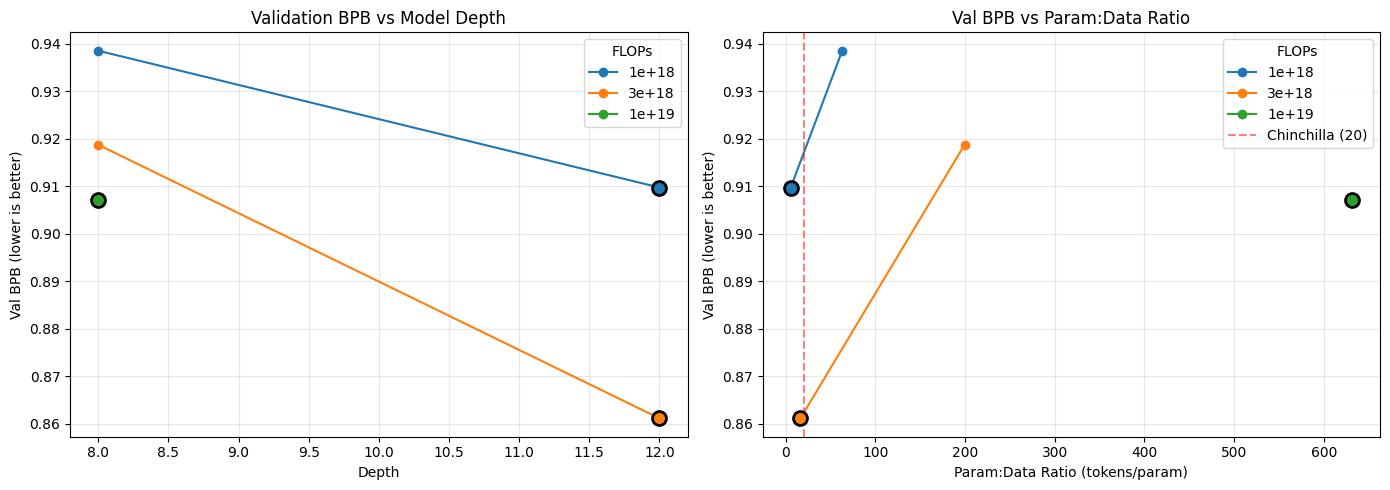

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Val BPB vs Depth
ax = axes[0]
for flops in flops_budgets:
    subset = df[df['flops_budget'] == flops].sort_values('depth')
    ax.plot(subset['depth'], subset['val_bpb'], 'o-', label=f'{flops:.0e}')
    # Mark the best (lowest)
    best_idx = subset['val_bpb'].idxmin()
    best = subset.loc[best_idx]
    ax.scatter([best['depth']], [best['val_bpb']], s=100, zorder=5, edgecolors='black', linewidths=2)

ax.set_xlabel('Depth')
ax.set_ylabel('Val BPB (lower is better)')
ax.set_title('Validation BPB vs Model Depth')
ax.legend(title='FLOPs')
ax.grid(True, alpha=0.3)

# Plot 2: Val BPB vs Param:Data Ratio
ax = axes[1]
for flops in flops_budgets:
    subset = df[df['flops_budget'] == flops].sort_values('param_data_ratio')
    ax.plot(subset['param_data_ratio'], subset['val_bpb'], 'o-', label=f'{flops:.0e}')
    best_idx = subset['val_bpb'].idxmin()
    best = subset.loc[best_idx]
    ax.scatter([best['param_data_ratio']], [best['val_bpb']], s=100, zorder=5, edgecolors='black', linewidths=2)

ax.axvline(x=20, color='red', linestyle='--', alpha=0.5, label='Chinchilla (20)')
ax.set_xlabel('Param:Data Ratio (tokens/param)')
ax.set_ylabel('Val BPB (lower is better)')
ax.set_title('Val BPB vs Param:Data Ratio')
ax.legend(title='FLOPs')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()